# Machine Learning

```mermaid
flowchart LR
A["Hypothesis Testing AKA AB Testing"] --> B[Compare 2 variables] 
B --> C[Num vs Num] --> D0{Normal?} -->|Yes|P[Pearsons Correlation Test]
D0 -->|No|S[Spearmans Correlation Test]
B --> C2[Num vs Bin] --> D{Normal?} -->|Yes| T[T Test]
D -->|No| W[Wilcox test]
B --> C3[NUm vs Cat] -->D2{Normal?} -->|Yes|ANOVA
D2 -->|No|K[Kruskal Wallis]
```

### Cheat Sheet 

|Test| Estimate| Command | Example|
|----|---------|----------|-------|
|Pearsons| correlation |cor.test(num1, num2)|`df %>% with(cor.test(num1, num2))`|
|Spearmans| correlation | cor.test(num1, num2, method='spearman')|`df %>% with(cor.test(num1, num2, method='spearman'))`|
|T-Test| mean difference |t.test(num ~ bin)|`df %>% with(t.test(num ~ bin))`|
|Wilcox Rank sum test| ... |wilcox.test(num ~ bin)|`df %>% with(wilcox.test(num ~ bin))`|
|ANOVA| difference in variance |aov(num ~ cat)|`df %>% with(aov(num ~ cat)) %>% summary()`|
|Kruskal Wallis test| ... |kruskal.test(num ~ cat)|`df %>% with(kruskal.test(num ~ cat))`|
|Chisquared-Test| observed vs expected frequencies |chisq.test(cat1 ~ cat2)|`df %>% select(cat1 , cat2) %>% table() %>% chisq.test`|


In [5]:
library(tidyverse)

In [2]:
data(mtcars)
data(iris)
data(penguins)

In [6]:
mtcars |> tibble()

# A tibble: 32 × 11
     mpg   cyl  disp    hp  drat    wt  qsec    vs    am  gear  carb
   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1  21       6  160    110  3.9   2.62  16.5     0     1     4     4
 2  21       6  160    110  3.9   2.88  17.0     0     1     4     4
 3  22.8     4  108     93  3.85  2.32  18.6     1     1     4     1
 4  21.4     6  258    110  3.08  3.22  19.4     1     0     3     1
 5  18.7     8  360    175  3.15  3.44  17.0     0     0     3     2
 6  18.1     6  225    105  2.76  3.46  20.2     1     0     3     1
 7  14.3     8  360    245  3.21  3.57  15.8     0     0     3     4
 8  24.4     4  147.    62  3.69  3.19  20       1     0     4     2
 9  22.8     4  141.    95  3.92  3.15  22.9     1     0     4     2
10  19.2     6  168.   123  3.92  3.44  18.3     1     0     4     4
# ℹ 22 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
mtcars |> with(cor.test(hp, drat, method='spearman'))

Warning message:
In cor.test.default(hp, drat, method = "spearman") :
  Cannot compute exact p-value with ties



	Spearman's rank correlation rho

data:  hp and drat
S = 8293.8, p-value = 0.002278
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
-0.520125 


In [11]:
penguins |> 
  with(t.test(body_mass ~ sex))


	Welch Two Sample t-test

data:  body_mass by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [12]:
penguins |> 
  with(wilcox.test(body_mass ~ sex))


	Wilcoxon rank sum test with continuity correction

data:  body_mass by sex
W = 6874.5, p-value = 1.813e-15
alternative hypothesis: true location shift is not equal to 0


In [14]:
penguins |>
  with(aov(body_mass ~ species)) |> summary()

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [15]:
penguins |>
  with(kruskal.test(body_mass ~ species)) 


	Kruskal-Wallis rank sum test

data:  body_mass by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


In [20]:
penguins |> 
  select(species, sex) |> 
  table() |> 
  chisq.test()


	Pearson's Chi-squared test

data:  table(select(penguins, species, sex))
X-squared = 0.048607, df = 2, p-value = 0.976


#### Machine Learning


```mermaid
flowchart LR

ML --> S[Supervised] 
ML --> Unsupervised


S --> N[Numeric]
S --> C[Categorical]

N --> R[Regression]
C --> C2[Classification]


R --> S2[Simple Linear Regression]
R --> M[Multi Linear Regreesion]
R --> D[Decision Tree Regression]
R --> S3[SVM Regression]
R --> E{Ensemble} --> R2[Random Forest Regression]

C2 --> B[Binary]
C2 --> C3[Categorical]

B --> L[Logistic Regression]
C3 --> D2[Decision tree classification]
C3 --> S4[SVM classification]
C3 --> K[K-Nearest Neighbors]
C3 --> E2{Ensemble} --> R3[Random Forest Classification]
E2 --> X[XGBoost]


```

### Regressions

$$
y = mx + c
$$

y = **dependent variable** or **label** or **outcome**

x = **independent varable** or **feature** or **exposure** or **treatment**

m = **gradient**, how much **x** increases with each unit increase in **y**

c = **intercept**, the value of **y** when **x** == 0 or the point where the line intersects with the y axis

In [59]:
#remember to run once
install.packages("broom.helpers")

Installing package into ‘/home/ikakke/R/x86_64-pc-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cloud.r-project.org/src/contrib/broom.helpers_1.21.0.tar.gz'
Content type 'application/x-gzip' length 207172 bytes (202 KB)
downloaded 202 KB

* installing *source* package ‘broom.helpers’ ...
** this is package ‘broom.helpers’ version ‘1.21.0’
** package ‘broom.helpers’ successfully unpacked and MD5 sums checked
** using staged installation
** R
** data
*** moving datasets to lazyload DB
** inst
** byte-compile and prepare package for lazy loading
** help
*** installing help indices
*** copying figures
** building package indices
** installing vignettes
** testing if installed package can be loaded from temporary location
** testing if installed package can be loaded from final location
** testing if installed package keeps a record of temporary installation path
* DONE (broom.helpers)

The downloaded source packages are in
	‘/tmp/RtmpIR0qEq/downloaded_packages’


In [54]:
#load libraries
library(tidyverse)
library(broom)
library(gtsummary)

In [61]:
#set options
set.seed(101)

In [22]:
#import dataset
nhanes <- read_csv("../data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn, Work, BMICatUnder20yrs, BMI...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCirc, Height, BMI, Pulse, BPSys...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [62]:
nhanes |> 
  filter(Age <= 18) |> 
  sample_n(100) |> 
  select(Height, Age) |> 
  filter(!is.na(Age), !is.na(Height)) -> random.kids

In [63]:
random.kids

# A tibble: 77 × 2
   Height   Age
    <dbl> <dbl>
 1   152.    11
 2   130.     7
 3   146.    10
 4   102.     3
 5   120.     5
 6   123.     6
 7   124.     7
 8   163.    13
 9   164.    11
10   101.     3
# ℹ 67 more rows
# ℹ Use `print(n = ...)` to see more rows

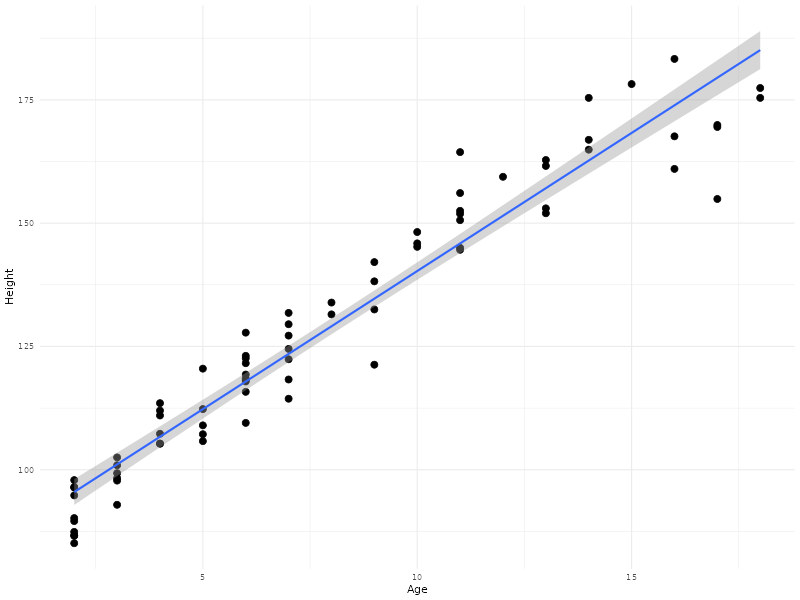

`geom_smooth()` using formula = 'y ~ x'

In [64]:
random.kids |> 
  ggplot() + aes(y=Height, x=Age) + geom_point(size=3) + theme_minimal() + geom_smooth(method=lm)

In [65]:
lm(Height ~ Age, data=random.kids) |> summary()


Call:
lm(formula = Height ~ Age, data = random.kids)

Residuals:
     Min       1Q   Median       3Q      Max 
-24.5864  -5.0861   0.6144   4.9141  18.5141 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  84.2851     1.6054   52.50   <2e-16 ***
Age           5.6001     0.1743   32.13   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.154 on 75 degrees of freedom
Multiple R-squared:  0.9323,	Adjusted R-squared:  0.9314 
F-statistic:  1032 on 1 and 75 DF,  p-value: < 2.2e-16


In [66]:
cor(random.kids$Height, random.kids$Age) ^ 2

[1] 0.9322714

In [67]:
lm(Height ~ Age, data=random.kids) |> glance()

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic  p.value    df logLik   AIC   BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>    <dbl> <dbl>  <dbl> <dbl> <dbl>    <dbl>       <int> <int>
1     0.932         0.931  7.15     1032. 1.35e-45     1  -260.  526.  533.    3838.          75    77

In [68]:
lm(Height ~ Age, data=random.kids) |> tidy()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    84.3      1.61       52.5 6.82e-61
2 Age             5.60     0.174      32.1 1.35e-45

In [69]:
lm(Height ~ Age, data=random.kids) |> tbl_regression()

<R HTML widget HTML Widget>

In [70]:
random.kids

# A tibble: 77 × 2
   Height   Age
    <dbl> <dbl>
 1   152.    11
 2   130.     7
 3   146.    10
 4   102.     3
 5   120.     5
 6   123.     6
 7   124.     7
 8   163.    13
 9   164.    11
10   101.     3
# ℹ 67 more rows
# ℹ Use `print(n = ...)` to see more rows

In [71]:
model1 = lm(Height ~ Age, data=random.kids)

In [73]:
predicted_height = predict(model1, newdata = random.kids)

In [74]:
random.kids$predicted_height = predicted_height

In [75]:
random.kids

# A tibble: 77 × 3
   Height   Age predicted_height
    <dbl> <dbl>            <dbl>
 1   152.    11             146.
 2   130.     7             123.
 3   146.    10             140.
 4   102.     3             101.
 5   120.     5             112.
 6   123.     6             118.
 7   124.     7             123.
 8   163.    13             157.
 9   164.    11             146.
10   101.     3             101.
# ℹ 67 more rows
# ℹ Use `print(n = ...)` to see more rows

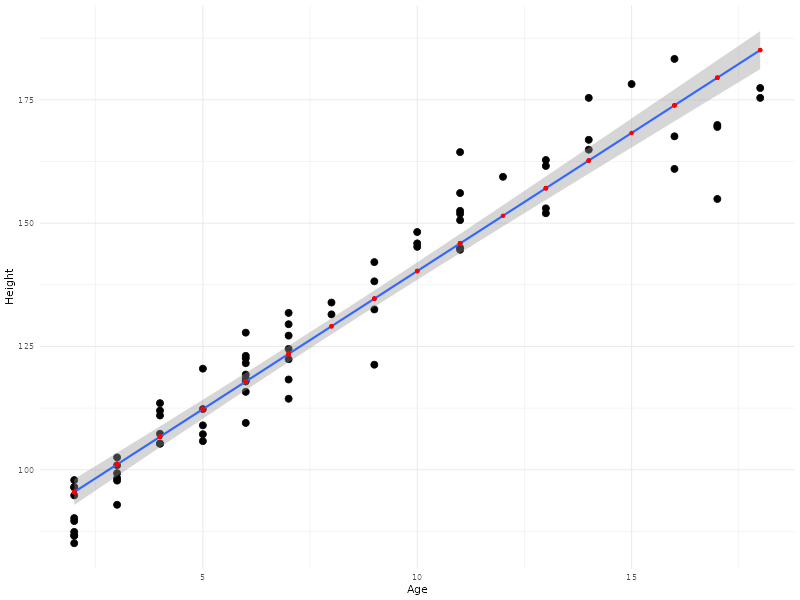

`geom_smooth()` using formula = 'y ~ x'

In [83]:
random.kids |> 
  ggplot() + 
    aes(x=Age, y=Height) + 
    geom_point(size=3) + 
    theme_minimal() + 
    geom_smooth(method=lm) + 
    geom_point(aes(y=predicted_height), color='red')